In [1]:
import pandas as pd

## give median and mean value for LOO task

In [18]:
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.model_selection import LeaveOneOut
import numpy as np
import matplotlib.pyplot as plt

In [12]:
sel_target_data_clean = pd.read_csv("../data/sel_target_data_clean.csv")
target_ddG = sel_target_data_clean['ddG'].to_numpy()
loo = LeaveOneOut()
tot_val_y = []
tot_val_median = []
tot_val_mean = []
for train_idx,val_idx in loo.split(target_ddG):
    train_y,val_y = target_ddG[train_idx],target_ddG[val_idx]
    val_median = np.median(train_y)
    val_mean = np.mean(train_y)
    tot_val_y.append(val_y)
    tot_val_median.append(val_median)
    tot_val_mean.append(val_mean)
tot_val_y = np.array(tot_val_y)
tot_val_median = np.array(tot_val_median)
tot_val_mean = np.array(tot_val_mean)

In [23]:
tot_val_mean

array([1.48662921, 1.48565403, 1.49140833, 1.48460638, 1.48347357,
       1.49332958, 1.48460638, 1.48565403, 1.47571527, 1.49071092,
       1.48565403, 1.49708518, 1.48460638, 1.48347357, 1.50135925,
       1.48460638, 1.48347357, 1.49271499, 1.48997986, 1.48088197,
       1.48754197, 1.48754197, 1.50097212, 1.49847321, 1.48347357,
       1.49207539, 1.50767969, 1.50422593, 1.49976337, 1.48088197,
       1.49557764, 1.50826407, 1.50647495, 1.50388712, 1.48565403,
       1.48223926, 1.50826407, 1.48840043, 1.51787955, 1.48921123,
       1.49071092, 1.48223926, 1.48921123, 1.48662921, 1.48460638,
       1.48565403, 1.48840043, 1.50319415, 1.48662921, 1.48565403,
       1.48754197, 1.48662921, 1.48662921, 1.48754197, 1.48662921])

In [17]:
median_r2 = r2_score(tot_val_y,tot_val_median)
median_mae = mean_absolute_error(tot_val_y,tot_val_median)
mean_r2 = r2_score(tot_val_y,tot_val_mean)
mean_mae = mean_absolute_error(tot_val_y,tot_val_mean)
print(f"median_r2: {median_r2:.4f}, median_mae: {median_mae:.4f}")
print(f"mean_r2: {mean_r2:.4f}, mean_mae: {mean_mae:.4f}")

median_r2: -0.1390, median_mae: 0.3380
mean_r2: -0.0374, mean_mae: 0.3778


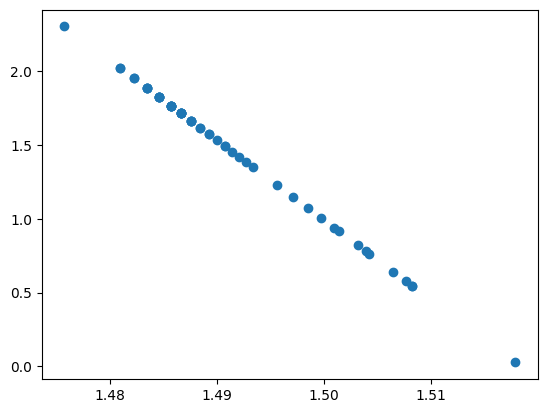

In [21]:
plt.scatter(tot_val_mean,tot_val_y)

## one-hot

In [58]:
import pandas as pd
import numpy as np
import warnings,glob
from rxnpredict.descriptors.desc import get_smi_desc_map
from rxnpredict.evaluate.eval import get_val_score_add_data
import optuna
from functools import partial
from optuna.samplers import TPESampler
from rxnpredict.models.hyperopt import rf_objective,et_objective,mlp_objective,ada_objective,bg_objective,dt_objective,gb_objective,xgb_objective,lgbm_objective
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,AdaBoostRegressor,BaggingRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
warnings.filterwarnings("ignore")

merge_method = "delta"
dist_type = "euclidean"
random_state = 1024
n_estimators = 50
descriptor_target_pearsonr_threshold = 0.2
descriptor_pearsonr_threshold = 0.95
base_rct_keys = ["Reactant1","Reactant2"]
target_rct_keys = ["Reactant1","Reactant2"]
base_sol_keys = ["Solvents"]
target_sol_keys = ["Solvents"]
base_rgt_keys = ["Reagents"]
target_rgt_keys = ["Reagents"]
base_ts_key = ["Reactant2","Reagent5"]
target_ts_key = ["Reactant2","Reagent2"]
selection_inf = {
            "type": "loo",
            "fold": 10,
            "metric": ["r2","mae"]}

In [26]:
best_model = GradientBoostingRegressor(n_estimators=117, min_samples_split=5, max_depth=3, random_state=1024)

In [31]:
sel_base_data_clean = pd.read_csv("../data/sel_base_data_clean.csv")
sel_target_data_clean = pd.read_csv("../data/sel_target_data_clean.csv")
sel_base_data_clean = sel_base_data_clean.fillna("")
sel_target_data_clean = sel_target_data_clean.fillna("")
base_rct1_smi = sel_base_data_clean["Reactant1"].tolist()
base_rct2_smi = sel_base_data_clean["Reactant2"].tolist()
base_rgt1_smi = sel_base_data_clean["Reagent1"].tolist() # base
base_rgt2_smi = sel_base_data_clean["Reagent2"].tolist() # tbab
base_rgt3_smi = sel_base_data_clean["Reagent3"].tolist() # 
base_rgt4_smi = sel_base_data_clean["Reagent4"].tolist() # catalyst
base_lig_smi = sel_base_data_clean["Reagent5"].tolist()
base_ddG = sel_base_data_clean["ddG"].to_numpy()

target_rct1_smi = sel_target_data_clean["Reactant1"].tolist()
target_rct2_smi = sel_target_data_clean["Reactant2"].tolist()
target_rgt1_smi = sel_target_data_clean["Reagent3"].tolist() # base
target_rgt2_smi = sel_target_data_clean["Reagent4"].tolist() # tbab
target_rgt3_smi = [""] * len(sel_target_data_clean)
target_rgt4_smi = sel_target_data_clean["Reagent1"].tolist() # catalyst
target_lig_smi = sel_target_data_clean["Reagent2"].tolist()
target_ddG = sel_target_data_clean["ddG"].to_numpy()

In [52]:
rct1_smi_oh_map = get_smi_desc_map(base_rct1_smi + target_rct1_smi,{"descriptor":"OneHot"})
rct2_smi_oh_map = get_smi_desc_map(base_rct2_smi + target_rct2_smi,{"descriptor":"OneHot"})
rgt1_smi_oh_map = get_smi_desc_map(base_rgt1_smi + target_rgt1_smi,{"descriptor":"OneHot"})
rgt2_smi_oh_map = get_smi_desc_map(base_rgt2_smi + target_rgt2_smi,{"descriptor":"OneHot"})
rgt3_smi_oh_map = get_smi_desc_map(base_rgt3_smi + target_rgt3_smi,{"descriptor":"OneHot"})
rgt4_smi_oh_map = get_smi_desc_map(base_rgt4_smi + target_rgt4_smi,{"descriptor":"OneHot"})
lig_smi_oh_map = get_smi_desc_map(base_lig_smi + target_lig_smi,{"descriptor":"OneHot"})

base_X = np.array([np.concatenate(
    [rct1_smi_oh_map[rct1_smi],rct2_smi_oh_map[rct2_smi],rgt1_smi_oh_map[rgt1_smi],rgt2_smi_oh_map[rgt2_smi],rgt3_smi_oh_map[rgt3_smi],rgt4_smi_oh_map[rgt4_smi],lig_smi_oh_map[lig_smi]]) for \
    rct1_smi,rct2_smi,rgt1_smi,rgt2_smi,rgt3_smi,rgt4_smi,lig_smi in zip(base_rct1_smi,base_rct2_smi,base_rgt1_smi,base_rgt2_smi,base_rgt3_smi,base_rgt4_smi,base_lig_smi)])
target_X = np.array([np.concatenate(
    [rct1_smi_oh_map[rct1_smi],rct2_smi_oh_map[rct2_smi],rgt1_smi_oh_map[rgt1_smi],rgt2_smi_oh_map[rgt2_smi],rgt3_smi_oh_map[rgt3_smi],rgt4_smi_oh_map[rgt4_smi],lig_smi_oh_map[lig_smi]]) for \
    rct1_smi,rct2_smi,rgt1_smi,rgt2_smi,rgt3_smi,rgt4_smi,lig_smi in zip(target_rct1_smi,target_rct2_smi,target_rgt1_smi,target_rgt2_smi,target_rgt3_smi,target_rgt4_smi,target_lig_smi)])


In [53]:
va_Y,va_P,score_map = get_val_score_add_data(best_model,base_X,base_ddG,target_X,target_ddG,
                                    selection_inf=selection_inf,merge_method=merge_method,topk=300,dist_type=dist_type)

Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


In [54]:
score_map

{'r2': 0.3683439230464761, 'mae': 0.23047720397991991}

In [61]:
n_trials = 15
X = target_X
base_y = base_ddG
y = target_ddG
topk = 300

In [62]:
for model_name in ["gb","rf","et","mlp","ada","bg","dt","xgb","lgbm"]:
    res = glob.glob(f"./results/base_line_oh_{model_name}_*.npy")
    if len(res) > 0:
        print(f"oh Model {model_name} already exists")
        continue
    sampler = TPESampler(n_startup_trials=5, seed=random_state)
    study = optuna.create_study(direction='maximize',sampler=sampler)
    if model_name == 'rf':
        optimize_func = partial(rf_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = RandomForestRegressor(**study.best_params, random_state=random_state)
    elif model_name == 'et':
        optimize_func = partial(et_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = ExtraTreesRegressor(**study.best_params, random_state=random_state)
    elif model_name == 'mlp':
        optimize_func = partial(mlp_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = MLPRegressor(**study.best_params, random_state=random_state)
    elif model_name == 'ada':
        optimize_func = partial(ada_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = AdaBoostRegressor(**study.best_params, random_state=random_state)
    elif model_name == 'bg':
        optimize_func = partial(bg_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = BaggingRegressor(**study.best_params, random_state=random_state)
    elif model_name == 'dt':
        optimize_func = partial(dt_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = DecisionTreeRegressor(**study.best_params)
    elif model_name == 'gb':
        optimize_func = partial(gb_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = GradientBoostingRegressor(**study.best_params, random_state=random_state)
    elif model_name == 'xgb':
        optimize_func = partial(xgb_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = XGBRegressor(**study.best_params, random_state=random_state)
    elif model_name == 'lgbm':
        optimize_func = partial(lgbm_objective, base_X=base_X,base_y=base_y,X=X,y=y,
                                selection_inf=selection_inf,random_state=random_state,
                                merge_method=merge_method,topk=topk,dist_type=dist_type)
        study.optimize(optimize_func, n_trials=n_trials)
        best_model = LGBMRegressor(**study.best_params, random_state=random_state)

    va_Y,va_P,score_map = get_val_score_add_data(best_model,base_X,base_y,X,y,
                                selection_inf=selection_inf,merge_method=merge_method,topk=topk,dist_type=dist_type)
    print(f"[INFO] !!!!!!!!!!!!! {model_name.upper()} OH R2: {score_map['r2']:.4f} !!!!!!!!!!!!!")
    
    np.save(f"./results/base_line_oh_{model_name}_{score_map['r2']}.npy",score_map)

[I 2025-12-25 05:08:00,160] A new study created in memory with name: no-name-066fcbad-a92c-4f1e-ac18-00824dbdabeb


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-25 05:08:33,153] Trial 0 finished with value: 0.35895874523695825 and parameters: {'n_estimators': 212, 'min_samples_split': 6, 'max_depth': 33}. Best is trial 0 with value: 0.35895874523695825.


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-25 05:09:05,186] Trial 1 finished with value: 0.36750470481696995 and parameters: {'n_estimators': 215, 'min_samples_split': 4, 'max_depth': 46}. Best is trial 1 with value: 0.36750470481696995.


...

Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-25 06:15:27,831] Trial 12 finished with value: 0.38262081676234516 and parameters: {'n_estimators': 194, 'min_samples_split': 5, 'max_depth': 44}. Best is trial 6 with value: 0.39103800268724365.


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300


[I 2025-12-25 06:17:45,710] Trial 13 finished with value: 0.383496622367127 and parameters: {'n_estimators': 144, 'min_samples_split': 3, 'max_depth': 50}. Best is trial 6 with value: 0.39103800268724365.


Evalutaion process: merge method delta, similarity evaluation True, similarity evaluation based on valid, distance type euclidean, topk 300
